# Q4. 梯度下降收敛实验

用 PyTorch 实现对 $f(x) = x^4 - 3x^3 + 2$ 的梯度下降，初始 $x = 4.0$。

分别用 `lr=0.01` 和 `lr=0.5` 运行 200 步，打印最终 $x$ 和 loss。

观察并回答：`lr=0.5` 时会发生什么？这和 PPO 的 Clipping 解决的是同一类问题吗？

## 手算：梯度是什么

$$f(x) = x^4 - 3x^3 + 2$$

$$f'(x) = 4x^3 - 9x^2$$

在初始点 $x = 4.0$：

$$f'(4) = 4(64) - 9(16) = 256 - 144 = 112$$

梯度下降的更新规则：$x \leftarrow x - \text{lr} \cdot f'(x)$

- `lr=0.01`：第一步 $x = 4.0 - 0.01 \times 112 = 2.88$，步子合理，逐渐收敛
- `lr=0.5`：第一步 $x = 4.0 - 0.5 \times 112 = -52$，直接飞出去，**发散**

In [1]:
import torch

def f(x):
    return x**4 - 3*x**3 + 2

def run_gd(lr, steps=200):
    x = torch.tensor(4.0, requires_grad=True)
    for step in range(steps):
        loss = f(x)
        loss.backward()
        with torch.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
        if not torch.isfinite(x):
            print(f"  [step {step+1}] diverged (x={x.item():.2e})")
            return
    print(f"  x = {x.item():.6f},  loss = {f(x).item():.6f}")

print("lr=0.01:")
run_gd(lr=0.01)

print("lr=0.5:")
run_gd(lr=0.5)

lr=0.01:
  x = 2.250000,  loss = -6.542971
lr=0.5:
  [step 4] diverged (x=inf)


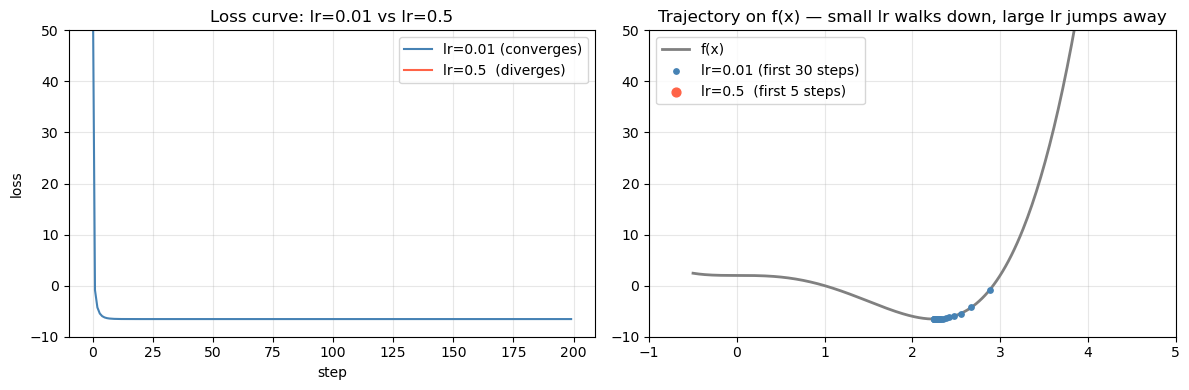

In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def collect_trajectory(lr, steps=200):
    xs = []
    x = torch.tensor(4.0, requires_grad=True)
    for _ in range(steps):
        xs.append(x.item())
        loss = f(x)
        loss.backward()
        with torch.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
        if not torch.isfinite(x):
            break
    return xs

traj_slow = collect_trajectory(0.01)
traj_fast = collect_trajectory(0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: loss curve
ax = axes[0]
losses_slow = [f(torch.tensor(xv)).item() for xv in traj_slow]
losses_fast = [f(torch.tensor(xv)).item() for xv in traj_fast]
ax.plot(losses_slow, label='lr=0.01 (converges)', color='steelblue')
ax.plot(losses_fast, label='lr=0.5  (diverges)',  color='tomato')
ax.set_ylim(-10, 50); ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.set_title('Loss curve: lr=0.01 vs lr=0.5')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: function + trajectory
ax2 = axes[1]
xs_plot = np.linspace(-0.5, 4.5, 300)
ys_plot = xs_plot**4 - 3*xs_plot**3 + 2
ax2.plot(xs_plot, ys_plot, color='gray', lw=2, label='f(x)')
ax2.scatter(traj_slow[:30], [f(torch.tensor(xv)).item() for xv in traj_slow[:30]],
            s=15, color='steelblue', label='lr=0.01 (first 30 steps)', zorder=3)
ax2.scatter(traj_fast[:5],  [f(torch.tensor(xv)).item() for xv in traj_fast[:5]],
            s=40, color='tomato',    label='lr=0.5  (first 5 steps)',  zorder=3)
ax2.set_ylim(-10, 50); ax2.set_xlim(-1, 5)
ax2.set_title('Trajectory on f(x) — small lr walks down, large lr jumps away')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Collect trajectory
traj = collect_trajectory(0.02, steps=80)
xs_plot = np.linspace(0, 4.5, 400)
ys_plot = xs_plot**4 - 3*xs_plot**3 + 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs_plot, ys_plot, color='gray', lw=2, label='f(x)')
ax.set_xlim(0, 4.5)
ax.set_ylim(-8, 20)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.grid(True, alpha=0.3)

# Elements to animate
point, = ax.plot([], [], 'o', color='tomato', ms=10, zorder=5)
trail, = ax.plot([], [], 'o-', color='steelblue', ms=3, alpha=0.4, lw=1)
title  = ax.set_title('')

def init():
    point.set_data([], [])
    trail.set_data([], [])
    return point, trail, title

def update(i):
    xv = traj[i]
    yv = xv**4 - 3*xv**3 + 2
    point.set_data([xv], [yv])
    trail.set_data(traj[:i+1], [v**4 - 3*v**3 + 2 for v in traj[:i+1]])
    title.set_text(f'lr=0.01  step={i+1:>3d}  x={xv:.4f}  f(x)={yv:.4f}')
    return point, trail, title

ani = FuncAnimation(fig, update, frames=len(traj),
                    init_func=init, interval=80, blit=True)
plt.close()
HTML(ani.to_jshtml())

## 观察与分析

### lr=0.5 时发生了什么？

$x=4.0$ 处梯度高达 $112$，`lr=0.5` 使第一步直接跳到 $x = 4 - 0.5 \times 112 = -52$。
新位置的梯度更大，下一步跳得更远，loss 爆炸至 NaN。这就是**梯度下降发散**：步子太大，越跳越偏。

### 这和 PPO Clipping 是同一类问题吗？

**是的，本质相同**——都是「单步更新幅度过大导致崩溃」。

| | 梯度下降 lr 过大 | PPO 没有 Clipping |
|---|---|---|
| 问题 | 参数一步跳太远，离最优点更远 | 策略一步变化太大，旧数据的梯度估计失效 |
| 后果 | loss 发散 | 策略崩溃，reward 断崖式下跌 |
| 解决方案 | 减小 lr / 用 Adam 自适应步长 | Clipping 限制新旧策略的比值 $r_t(\theta) \in [1-\epsilon, 1+\epsilon]$ |

PPO 的 Clipping 目标：

$$L^{\text{CLIP}} = \mathbb{E}\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\right)\right]$$

其中 $r_t(\theta) = \frac{\pi_\theta(a|s)}{\pi_{\theta_{\text{old}}}(a|s)}$ 是新旧策略的概率比。Clipping 强制这个比值不超过 $1 \pm \epsilon$，相当于给策略更新加了一个「步长上限」，防止单次更新把策略推到太远的地方。